# 01 — Data Exploration

EDA on the WildChat longitudinal cohort, redaction exclusion, and session numbering.

**Input:** `data/interim/wildchat_longitudinal.parquet` (1.7 GB, one row per conversation, already filtered to users with ≥10 conversations)

**Output:** `data/interim/conv_metadata.parquet` — one row per conversation with `session_number` assigned. Notebook 02 merges this back onto turns for feature extraction.

**Science check:** Inspect turn count distribution, session count distribution, and early/late window coverage before proceeding to feature engineering. Confirm redaction exclusion rate matches pre-specified expectation (~0.9%).

In [1]:
import random
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to path so src imports work
sys.path.insert(0, '..')

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

PARQUET_PATH = '../data/interim/wildchat_longitudinal.parquet'
BATCH_SIZE = 500

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Build Conversation Metadata (Single-Pass, Chunked)

We collect one row per conversation (not per turn) to keep the working set small.
Turn-level data stays on disk and is read in chunks during feature extraction (notebook 02).

In [2]:
import pyarrow.parquet as pq
import json
from tqdm.notebook import tqdm

def count_turns(conv_raw):
    turns = json.loads(conv_raw) if isinstance(conv_raw, str) else conv_raw
    return len(turns), sum(1 for t in turns if t.get('role') == 'user')

pf = pq.ParquetFile(PARQUET_PATH)
chunks = []

for batch in tqdm(pf.iter_batches(batch_size=BATCH_SIZE), desc='Reading conversations'):
    df_batch = batch.to_pandas()
    counts = df_batch['conversation'].apply(count_turns)
    df_batch['n_turns'] = counts.apply(lambda x: x[0])
    df_batch['n_user_turns'] = counts.apply(lambda x: x[1])
    chunks.append(df_batch[['conversation_id', 'hashed_ip', 'timestamp', 'redacted', 'n_turns', 'n_user_turns']])

conv_meta = pd.concat(chunks, ignore_index=True)
conv_meta['conversation_id'] = conv_meta['conversation_id'].astype(str)
conv_meta['hashed_ip'] = conv_meta['hashed_ip'].astype(str)
conv_meta['timestamp'] = pd.to_datetime(conv_meta['timestamp'], utc=True, errors='coerce')
print(f'Total conversations loaded: {len(conv_meta):,}')
conv_meta.head()

Reading conversations: 0it [00:00, ?it/s]

Total conversations loaded: 509,861


,conversation_id,hashed_ip,timestamp,redacted,n_turns,n_user_turns
0,101001,22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3...,2023-04-09 00:02:53+00:00,False,2,1
1,101007,846e43fb5fbb4b8cfbafa17083387aad62e58f5fb23482...,2023-04-09 00:06:29+00:00,False,2,1
2,101008,22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3...,2023-04-09 00:06:49+00:00,False,2,1
3,101012,22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3...,2023-04-09 00:08:41+00:00,False,2,1
4,101017,22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3...,2023-04-09 00:11:02+00:00,False,2,1


## 2. Exclude Redacted Conversations (Pre-Specified)

In [3]:
n_before = len(conv_meta)
conv_meta = conv_meta[~conv_meta['redacted']].copy()
n_removed = n_before - len(conv_meta)
print(f'Removed {n_removed:,} redacted conversations ({n_removed / n_before:.2%})')
print(f'Remaining: {len(conv_meta):,} conversations, {conv_meta["hashed_ip"].nunique():,} users')

Removed 4,464 redacted conversations (0.88%)


Remaining: 505,397 conversations, 12,577 users


## 3. Assign Session Numbers (Chronological Rank per User)

In [4]:
from src.data.session_builder import assign_session_numbers

conv_meta = assign_session_numbers(
    conv_meta,
    user_col='hashed_ip',
    conv_col='conversation_id',
    time_col='timestamp',
)
print(conv_meta[['hashed_ip', 'conversation_id', 'timestamp', 'session_number']].head(10))

                                           hashed_ip conversation_id  \
0  22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3...          101001   
1  846e43fb5fbb4b8cfbafa17083387aad62e58f5fb23482...          101007   
2  22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3...          101008   
3  22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3...          101012   
4  22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3...          101017   
5  22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3...          101021   
6  86ec3573c37756aaada26c4327c8ed2ae82fe6d130ace5...          101029   
7  846e43fb5fbb4b8cfbafa17083387aad62e58f5fb23482...          101036   
8  cd827160f11893d3b1fdecf6e5985c4d1b7db5114a1159...          101058   
9  e49e258fbabeb7e0916d44b43e30ad77e61026bd8cb07c...          101005   

                  timestamp  session_number  
0 2023-04-09 00:02:53+00:00               1  
1 2023-04-09 00:06:29+00:00               1  
2 2023-04-09 00:06:49+00:00               2  
3 2023-04-09 00:08:41+0

## 4. Cohort Overview

In [5]:
n_users = conv_meta['hashed_ip'].nunique()
n_convs = len(conv_meta)
n_turns_total = conv_meta['n_turns'].sum()
ts_min = conv_meta['timestamp'].min()
ts_max = conv_meta['timestamp'].max()
span_days = (ts_max - ts_min).days

print(f'Users:              {n_users:>10,}')
print(f'Conversations:      {n_convs:>10,}')
print(f'Turns (total):      {n_turns_total:>10,}')
print(f'Avg convs/user:     {n_convs / n_users:>10.1f}')
print(f'Timestamp span:     {ts_min.date()} → {ts_max.date()} ({span_days} days)')
print()
print('Turn count distribution (per conversation):')
print(conv_meta['n_user_turns'].describe())

Users:                  12,577
Conversations:         505,397
Turns (total):       2,244,534
Avg convs/user:           40.2
Timestamp span:     2023-04-09 → 2024-04-29 (386 days)

Turn count distribution (per conversation):
count    505397.000000
mean          2.220565
std           2.960644
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         249.000000
Name: n_user_turns, dtype: float64


## 5. Session Count Distribution

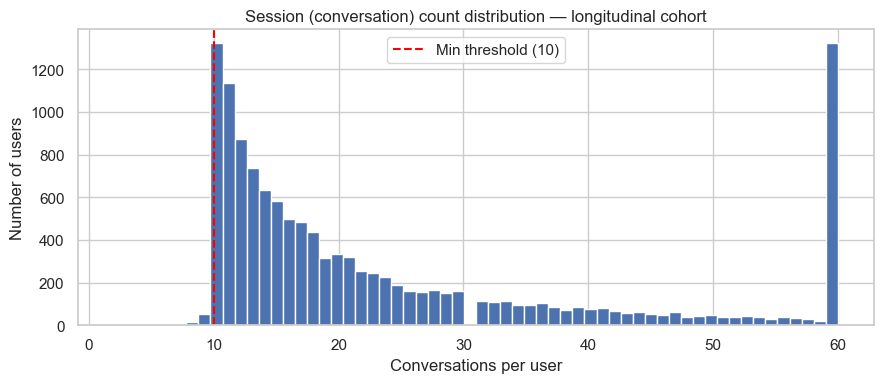

count    12577.000000
mean        40.123877
std        155.419868
min          2.000000
25%         12.000000
50%         17.000000
75%         30.000000
max       6459.000000
Name: session_number, dtype: float64


In [6]:
sessions_per_user = conv_meta.groupby('hashed_ip')['session_number'].max()

fig, ax = plt.subplots(figsize=(9, 4))
sessions_per_user.clip(upper=60).hist(bins=60, ax=ax)
ax.axvline(10, color='red', linestyle='--', linewidth=1.5, label='Min threshold (10)')
ax.set_xlabel('Conversations per user')
ax.set_ylabel('Number of users')
ax.set_title('Session (conversation) count distribution — longitudinal cohort')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/01_session_count_distribution.png', dpi=150)
plt.show()

print(sessions_per_user.describe())

## 6. Turn Count Distribution (Right-Skewed — Log Transform Pre-Specified)

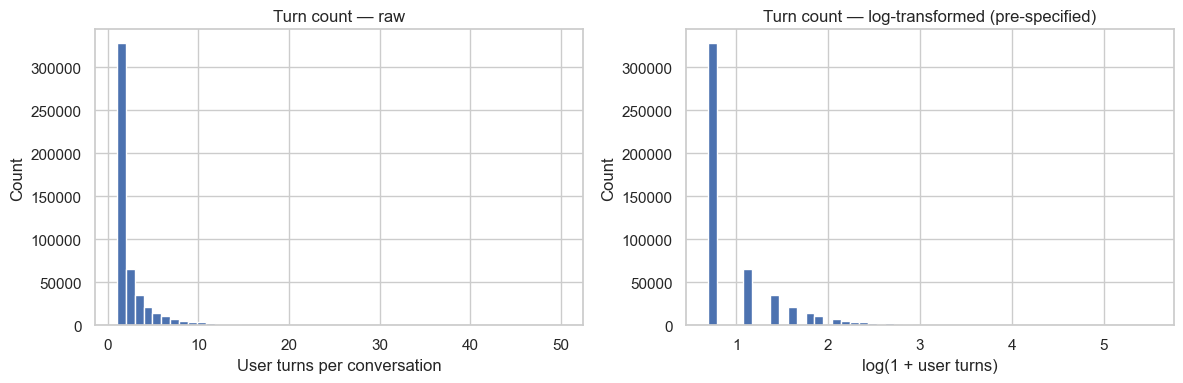

Median user turns per conversation: 1.0
Mean user turns per conversation:   2.2
Max user turns per conversation:    249


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

conv_meta['n_user_turns'].clip(upper=50).hist(bins=50, ax=axes[0])
axes[0].set_xlabel('User turns per conversation')
axes[0].set_ylabel('Count')
axes[0].set_title('Turn count — raw')

np.log1p(conv_meta['n_user_turns']).hist(bins=50, ax=axes[1])
axes[1].set_xlabel('log(1 + user turns)')
axes[1].set_ylabel('Count')
axes[1].set_title('Turn count — log-transformed (pre-specified)')

plt.tight_layout()
plt.savefig('../outputs/figures/01_turn_count_distribution.png', dpi=150)
plt.show()

print('Median user turns per conversation:', conv_meta['n_user_turns'].median())
print('Mean user turns per conversation:  ', conv_meta['n_user_turns'].mean().round(1))
print('Max user turns per conversation:   ', conv_meta['n_user_turns'].max())

## 7. Return Interval Distribution (Right-Skewed — Log Transform Pre-Specified)

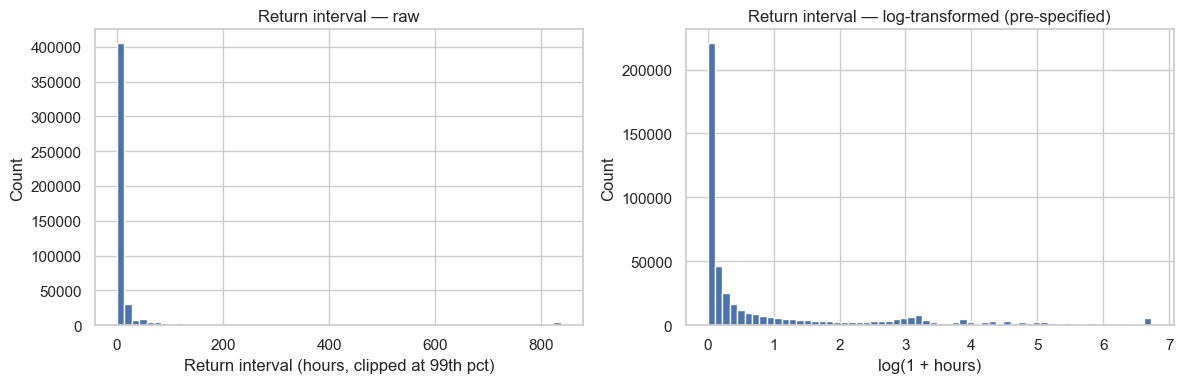

Median return interval: 0.2 hours
Mean return interval:   38.1 hours


In [8]:
# Compute per-user return intervals: time from end of conversation N to start of conversation N+1
# Here we use conversation timestamps as a proxy (top-level timestamp = last turn in conversation)
conv_sorted = conv_meta.sort_values(['hashed_ip', 'session_number'])
conv_sorted['return_interval_hours'] = (
    conv_sorted.groupby('hashed_ip')['timestamp']
    .diff()
    .dt.total_seconds() / 3600
)

return_intervals = conv_sorted['return_interval_hours'].dropna()
return_intervals_clipped = return_intervals.clip(upper=return_intervals.quantile(0.99))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

return_intervals_clipped.hist(bins=60, ax=axes[0])
axes[0].set_xlabel('Return interval (hours, clipped at 99th pct)')
axes[0].set_ylabel('Count')
axes[0].set_title('Return interval — raw')

np.log1p(return_intervals_clipped).hist(bins=60, ax=axes[1])
axes[1].set_xlabel('log(1 + hours)')
axes[1].set_ylabel('Count')
axes[1].set_title('Return interval — log-transformed (pre-specified)')

plt.tight_layout()
plt.savefig('../outputs/figures/01_return_interval_distribution.png', dpi=150)
plt.show()

print(f'Median return interval: {return_intervals.median():.1f} hours')
print(f'Mean return interval:   {return_intervals.mean():.1f} hours')

## 8. Early/Late Window Coverage

**Science check:** Confirm that a sufficient number of users have data in both the early window (sessions 1–3) AND the late window (sessions 10+). Users missing either window cannot be included in the predictive model.

In [9]:
has_early = conv_meta[conv_meta['session_number'] <= 3].groupby('hashed_ip').size() >= 1
has_late  = conv_meta[conv_meta['session_number'] >= 10].groupby('hashed_ip').size() >= 1

both = has_early.index[has_early].intersection(has_late.index[has_late])

print(f'Users with early window (sessions 1–3):      {has_early.sum():>7,}')
print(f'Users with late window (sessions 10+):       {has_late.sum():>7,}')
print(f'Users with both windows (modelling cohort):  {len(both):>7,}')
print()
print('All qualifying users have ≥10 sessions by construction, so both windows are guaranteed.')
print(f'Modelling cohort N = {len(both):,} users.')

Users with early window (sessions 1–3):       12,577
Users with late window (sessions 10+):        12,497
Users with both windows (modelling cohort):   12,497

All qualifying users have ≥10 sessions by construction, so both windows are guaranteed.
Modelling cohort N = 12,497 users.


## 9. Monthly Conversation Volume (Timestamp Span Check)

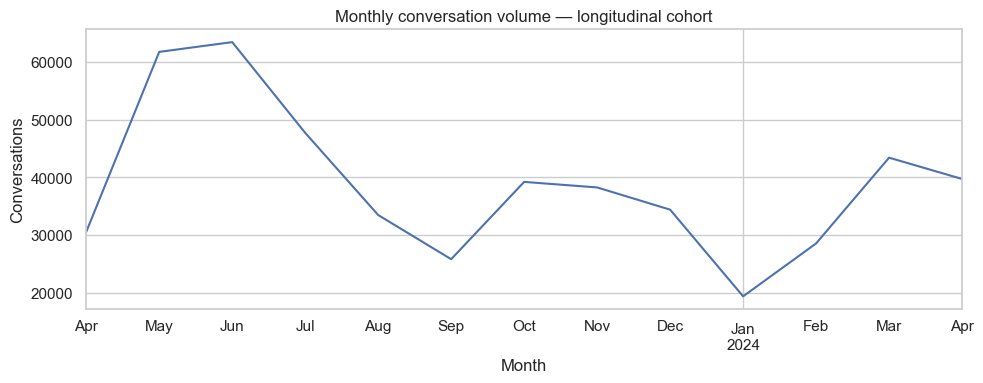

In [10]:
monthly = (
    conv_meta
    .set_index('timestamp')
    .resample('ME')['conversation_id']
    .count()
)

fig, ax = plt.subplots(figsize=(10, 4))
monthly.plot(ax=ax)
ax.set_xlabel('Month')
ax.set_ylabel('Conversations')
ax.set_title('Monthly conversation volume — longitudinal cohort')
plt.tight_layout()
plt.savefig('../outputs/figures/01_monthly_volume.png', dpi=150)
plt.show()

## 10. Save Conversation Metadata

In [11]:
# Add log-transformed columns here so they are available throughout the pipeline
conv_sorted['log_n_user_turns'] = np.log1p(conv_sorted['n_user_turns'])
conv_sorted['log_return_interval_hours'] = np.log1p(conv_sorted['return_interval_hours'].fillna(0))

out_path = '../data/interim/conv_metadata.parquet'
conv_sorted.to_parquet(out_path, index=False)
print(f'Saved {len(conv_sorted):,} rows to {out_path}')
print('Columns:', list(conv_sorted.columns))

Saved 505,397 rows to ../data/interim/conv_metadata.parquet
Columns: ['conversation_id', 'hashed_ip', 'timestamp', 'redacted', 'n_turns', 'n_user_turns', 'session_number', 'return_interval_hours', 'log_n_user_turns', 'log_return_interval_hours']
